<a href="https://colab.research.google.com/github/Bobby9800/STATSANDSCANS/blob/main/CreditCardPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

In [3]:
df_credit = pd.read_csv('credit_record.csv')
df_credit

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C
...,...,...,...
1048570,5150487,-25,C
1048571,5150487,-26,C
1048572,5150487,-27,C
1048573,5150487,-28,C


In [4]:
df_application = pd.read_csv('application_record.csv')
df_application

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438552,6840104,M,N,Y,0,135000.0,Pensioner,Secondary / secondary special,Separated,House / apartment,-22717,365243,1,0,0,0,NaN,1.0
438553,6840222,F,N,N,0,103500.0,Working,Secondary / secondary special,Single / not married,House / apartment,-15939,-3007,1,0,0,0,Laborers,1.0
438554,6841878,F,N,N,0,54000.0,Commercial associate,Higher education,Single / not married,With parents,-8169,-372,1,1,0,0,Sales staff,1.0
438555,6842765,F,N,Y,0,72000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21673,365243,1,0,0,0,NaN,2.0


In [5]:
df_credit.info()
df_application.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-

In [9]:
df_credit['ID'].duplicated().sum()

1002590

In [10]:
df_application['ID'].duplicated().sum()

47

In [11]:
df_application.isnull().sum()

,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0


In [12]:
# Compute mode status for Merging
mode_status = df_credit.groupby('ID')['STATUS'].agg(lambda x: x.mode()[0]).reset_index()
mode_status.rename(columns={'STATUS': 'mode_status'}, inplace=True)
mode_status = mode_status[mode_status['mode_status'] != 'X']

merged_df = pd.merge(df_application, mode_status, on='ID', how='inner')

In [13]:
mode_status.head()

,ID,mode_status
0,5001711,0
1,5001712,0
5,5001717,0
6,5001718,0
7,5001719,C


In [14]:
print(mode_status['mode_status'].unique())

['0' 'C' '1' '5' '2']


In [15]:
def label_status(status):
    if status in {"0", "1", "2", "3", "4", "5"}:
        return 'bad'
    elif status == 'C':
        return 'good'
    else:
        return 'unknown'

In [16]:
merged_df['mode_status'].value_counts()

,count
mode_status,
0,17522
C,12807
1,81
5,47
2,2


In [17]:
merged_df['label'] = merged_df['mode_status'].apply(label_status)

merged_df['label'].value_counts()

,count
label,
bad,17652
good,12807


In [18]:
merged_df['TARGET'] = merged_df['label'].apply(lambda x: 0 if x == 'bad' else 1)

merged_df['TARGET'].value_counts()

,count
TARGET,
0,17652
1,12807


In [19]:
merged_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,mode_status,label,TARGET
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,NaN,2.0,C,good,1
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,NaN,2.0,C,good,1
2,5008810,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,-3051,1,0,1,1,Sales staff,1.0,C,good,1
3,5008811,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,-3051,1,0,1,1,Sales staff,1.0,C,good,1
4,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,...,365243,1,0,0,0,NaN,1.0,0,bad,0


In [20]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30459 entries, 0 to 30458
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   30459 non-null  int64  
 1   CODE_GENDER          30459 non-null  object 
 2   FLAG_OWN_CAR         30459 non-null  object 
 3   FLAG_OWN_REALTY      30459 non-null  object 
 4   CNT_CHILDREN         30459 non-null  int64  
 5   AMT_INCOME_TOTAL     30459 non-null  float64
 6   NAME_INCOME_TYPE     30459 non-null  object 
 7   NAME_EDUCATION_TYPE  30459 non-null  object 
 8   NAME_FAMILY_STATUS   30459 non-null  object 
 9   NAME_HOUSING_TYPE    30459 non-null  object 
 10  DAYS_BIRTH           30459 non-null  int64  
 11  DAYS_EMPLOYED        30459 non-null  int64  
 12  FLAG_MOBIL           30459 non-null  int64  
 13  FLAG_WORK_PHONE      30459 non-null  int64  
 14  FLAG_PHONE           30459 non-null  int64  
 15  FLAG_EMAIL           30459 non-null 

In [21]:
merged_df.drop(columns=['mode_status', 'label'], inplace=True)

In [22]:
merged_df['ID'].duplicated().sum()

0

In [23]:
#missing values OCCUPATION_TYPE
merged_df.fillna({'OCCUPATION_TYPE': 'Unknown'}, inplace=True)

In [24]:
occupation_types = merged_df['OCCUPATION_TYPE'].unique()
print(occupation_types)

['Unknown' 'Sales staff' 'Accountants' 'Laborers' 'Managers' 'Drivers'
 'Core staff' 'Security staff' 'High skill tech staff' 'Cleaning staff'
 'Cooking staff' 'Low-skill Laborers' 'Medicine staff'
 'Private service staff' 'Secretaries' 'Waiters/barmen staff' 'HR staff'
 'IT staff' 'Realty agents']


In [25]:
# Compute age
merged_df['AGE'] = merged_df['DAYS_BIRTH'].apply(lambda x: abs(x) // 365)

# Compute credit history length
credit_history_length = df_credit.groupby('ID')['MONTHS_BALANCE'].apply(lambda x: x.max() - x.min()).reset_index()
credit_history_length.columns = ['ID', 'CREDIT_HISTORY_LENGTH']
merged_df = pd.merge(merged_df, credit_history_length, on='ID', how='left')

#  recent activity within the last 6 months
def recent_activity(months_balance):
    return 1 if any(month >= -6 for month in months_balance) else 0
recent_activity_flag = df_credit.groupby('ID')['MONTHS_BALANCE'].apply(recent_activity).reset_index()
recent_activity_flag.columns = ['ID', 'RECENT_ACTIVITY']
merged_df = pd.merge(merged_df, recent_activity_flag, on='ID', how='left')

#no of years employed
merged_df['YEARS_EMPLOYED'] = merged_df['DAYS_EMPLOYED'].apply(lambda x: abs(x) // 365)
merged_df['IS_UNEMPLOYED'] = merged_df['DAYS_EMPLOYED'].apply(lambda x: 1 if x > 0 else 0)

In [26]:
# Encode categorical variables
le = LabelEncoder()
merged_df['CODE_GENDER'] = le.fit_transform(merged_df['CODE_GENDER'])
merged_df['FLAG_OWN_CAR'] = le.fit_transform(merged_df['FLAG_OWN_CAR'])
merged_df['FLAG_OWN_REALTY'] = le.fit_transform(merged_df['FLAG_OWN_REALTY'])

# Convert categorical features to dummy variables
merged_df = pd.get_dummies(merged_df,
                           columns=['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
                                    'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE'],
                           drop_first=True)

#find booleans and cast to integers
bool_columns = merged_df.select_dtypes(include=['bool']).columns
merged_df[bool_columns] = merged_df[bool_columns].astype(int)

In [27]:
# Drop columns not neede
merged_df.drop(columns=['DAYS_BIRTH', 'DAYS_EMPLOYED'], inplace=True)

In [28]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30459 entries, 0 to 30458
Data columns (total 52 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   ID                                                 30459 non-null  int64  
 1   CODE_GENDER                                        30459 non-null  int64  
 2   FLAG_OWN_CAR                                       30459 non-null  int64  
 3   FLAG_OWN_REALTY                                    30459 non-null  int64  
 4   CNT_CHILDREN                                       30459 non-null  int64  
 5   AMT_INCOME_TOTAL                                   30459 non-null  float64
 6   FLAG_MOBIL                                         30459 non-null  int64  
 7   FLAG_WORK_PHONE                                    30459 non-null  int64  
 8   FLAG_PHONE                                         30459 non-null  int64  
 9   FLAG_E

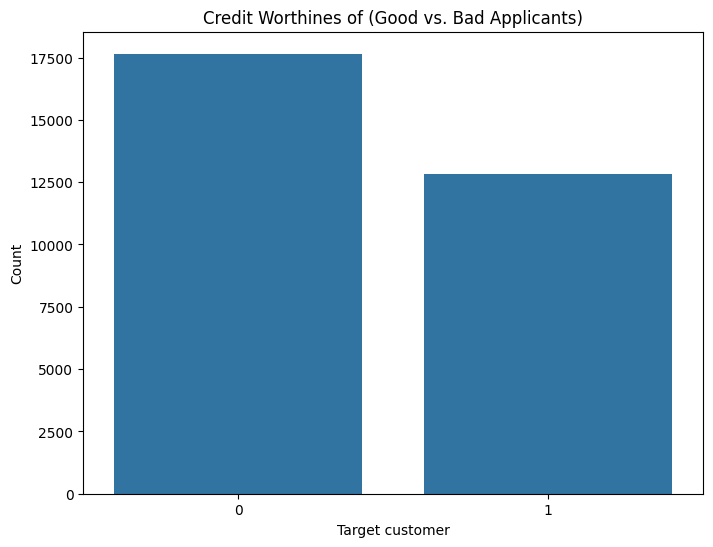

In [31]:
plt.figure(figsize=(8, 6))
sns.countplot(x='TARGET', data=merged_df)
plt.title('Credit Worthines of (Good vs. Bad Applicants)')
plt.xlabel('Target customer')
plt.ylabel('Count')
plt.show()

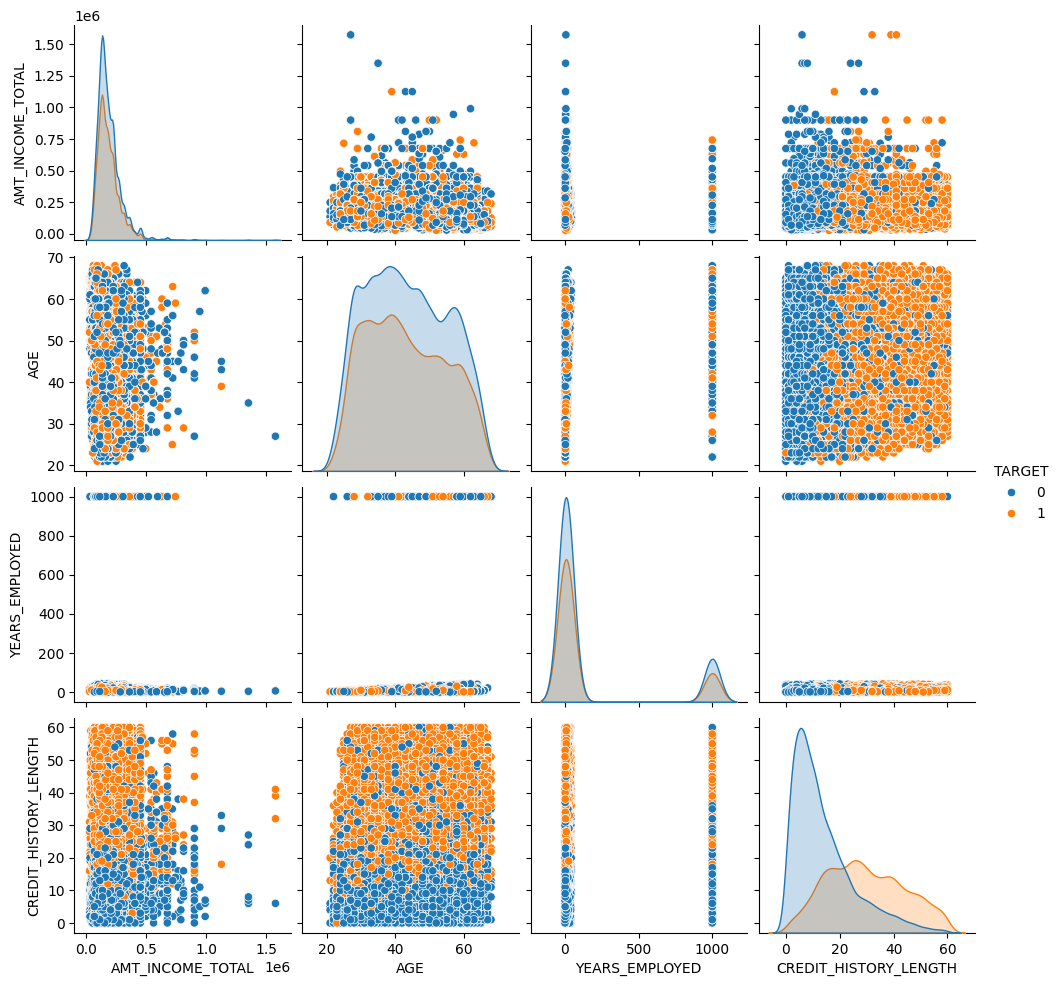

In [32]:
merged_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Pair Plot for numerical features
sns.pairplot(merged_df[['AMT_INCOME_TOTAL', 'AGE', 'YEARS_EMPLOYED', 'CREDIT_HISTORY_LENGTH', 'TARGET']],
             hue='TARGET')
plt.show()

In [33]:
merged_df.describe()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,...,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Unknown,OCCUPATION_TYPE_Waiters/barmen staff
count,3.045900e+04,30459.000000,30459.000000,30459.000000,30459.000000,3.045900e+04,30459.0,30459.000000,30459.000000,30459.000000,...,30459.000000,30459.000000,30459.000000,30459.000000,30459.000000,30459.000000,30459.000000,30459.000000,30459.000000,30459.000000
mean,5.077937e+06,0.327128,0.376539,0.674415,0.428281,1.857313e+05,1.0,0.222561,0.291014,0.090220,...,0.004826,0.081454,0.033849,0.009226,0.002167,0.096261,0.004202,0.016416,0.313897,0.004892
std,4.198823e+04,0.469172,0.484526,0.468601,0.742907,1.019321e+05,0.0,0.415973,0.454237,0.286501,...,0.069304,0.273535,0.180843,0.095607,0.046500,0.294953,0.064690,0.127069,0.464083,0.069771
min,5.008804e+06,0.000000,0.000000,0.000000,0.000000,2.700000e+04,1.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.041884e+06,0.000000,0.000000,0.000000,0.000000,1.215000e+05,1.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5.069369e+06,0.000000,0.000000,1.000000,0.000000,1.575000e+05,1.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5.114650e+06,1.000000,1.000000,1.000000,1.000000,2.250000e+05,1.0,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,5.150487e+06,1.000000,1.000000,1.000000,19.000000,1.575000e+06,1.0,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


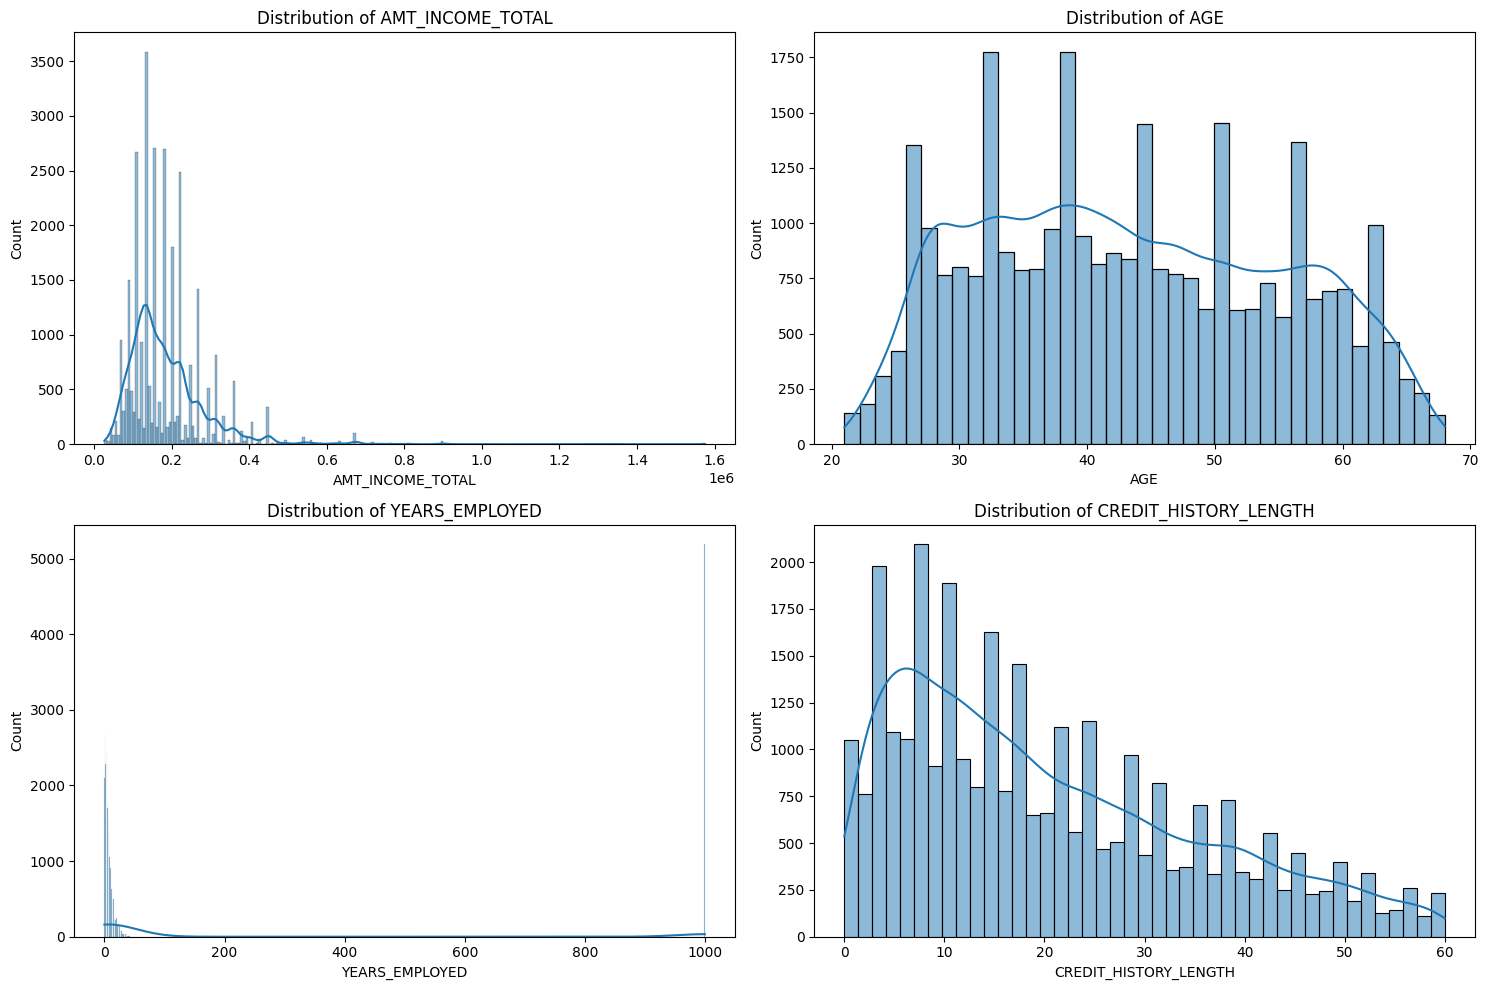

In [34]:
merged_df.replace([np.inf, -np.inf], np.nan, inplace=True)
plt.figure(figsize=(15, 10))
for i, col in enumerate(['AMT_INCOME_TOTAL', 'AGE', 'YEARS_EMPLOYED', 'CREDIT_HISTORY_LENGTH']):
    plt.subplot(2, 2, i + 1)
    sns.histplot(merged_df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

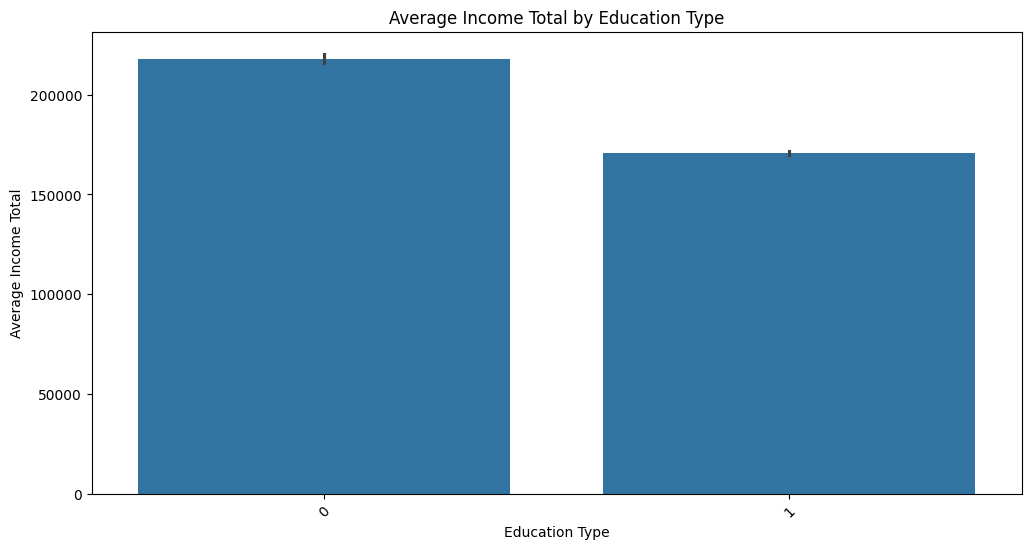

In [35]:
plt.figure(figsize=(12, 6))
sns.barplot(x='NAME_EDUCATION_TYPE_Secondary / secondary special', y='AMT_INCOME_TOTAL', data=merged_df)
plt.title('Average Income Total by Education Type')
plt.xlabel('Education Type')
plt.ylabel('Average Income Total')
plt.xticks(rotation=45)
plt.show()

In [36]:
X = merged_df.drop(columns=['ID', 'TARGET'])
y = merged_df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [37]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
# Logistic Regression for the Model
logreg = LogisticRegression(max_iter=1000)

logreg.fit(X_train_scaled, y_train)

y_pred = logreg.predict(X_test_scaled)
print("Logistic Regression Results:")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred))

Logistic Regression Results:
Confusion Matrix:
 [[4479  838]
 [1500 2321]]
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.84      0.79      5317
           1       0.73      0.61      0.67      3821

    accuracy                           0.74      9138
   macro avg       0.74      0.72      0.73      9138
weighted avg       0.74      0.74      0.74      9138

Accuracy Score: 0.7441453272050776
ROC AUC Score: 0.7249124678822483


In [39]:
# Random Forest Classification
rf = RandomForestClassifier()

rf.fit(X_train_scaled, y_train)

y_pred = rf.predict(X_test_scaled)

print("Random Forest Results:")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred))

Random Forest Results:
Confusion Matrix:
 [[4385  932]
 [1050 2771]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.82      0.82      5317
           1       0.75      0.73      0.74      3821

    accuracy                           0.78      9138
   macro avg       0.78      0.77      0.78      9138
weighted avg       0.78      0.78      0.78      9138

Accuracy Score: 0.7831035237469905
ROC AUC Score: 0.7749580053058002


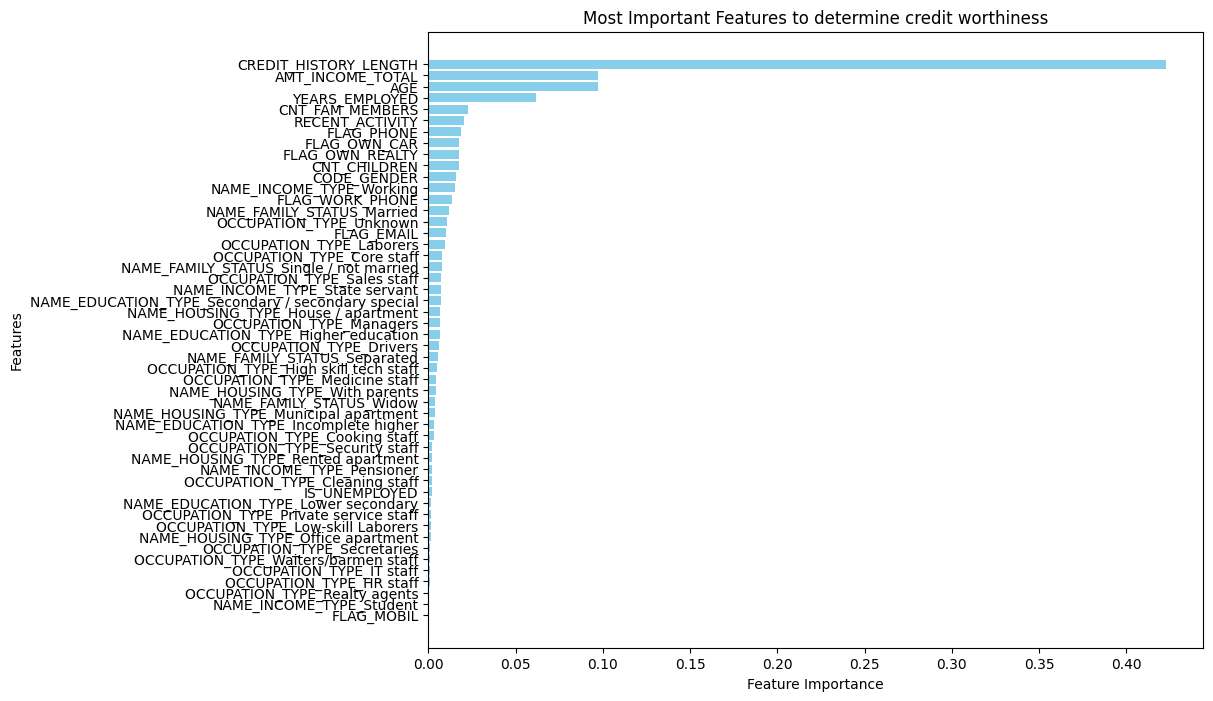

In [41]:
feature_names = X_train.columns if hasattr(X_train, 'columns') else [f'Feature {i}' for i in range(X_train.shape[1])]

#feature importance from the fitted RF
feature_importances = rf.feature_importances_


feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})


feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)


plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Most Important Features to determine credit worthiness')
plt.show()